# SDG Project - Analisi Esplorativa del Dataset
- Caricamento del dataset
- Descrizione del dataset
- Data Cleaning (gestione dei missing values) 
- 

In [1]:
# Import delle librerie principali
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento dei dataset
# Nota: dataset.csv utilizza ';' come separatore e ',' come separatore decimale per i valori numerici
df = pd.read_csv('dataset/dataset.csv', sep=';', decimal=',')
data_desc = pd.read_csv('dataset/data_descriptions.csv', sep=';')

print("Dataset caricati con successo!")

Dataset caricati con successo!


### 1. Descrizione dataset 
Verifichiamo la dimensione complessiva del dataset (numero di righe e colonne) e analizziamo i tipi di dato (`dtypes`) associati a ciascuna colonna.
Separiamo le colonne del dataset in **categoriche** (identificate dal tipo `object`/`string` o dal prefisso `text_format` nelle descrizioni) e **numeriche**. Eseguiamo infine `.describe()` separatamente per i due gruppi.

In [2]:
from IPython.display import display
# 1. Shape del dataset (righe, colonne)
print(f"Shape del dataset: {df.shape[0]} righe, {df.shape[1]} colonne\n")

# Prime 5 righe
print("--- Prime 5 righe del dataset ---")
display(df.head())

# Tipi di dato delle colonne (dtypes)
# print("\n--- Tipi di dato (dtypes) - Prime 20 colonne ---")
# display(df.dtypes.to_frame(name='dtype').head(20))

# Elenco variabili con prefisso text_format nelle descrizioni
tf_vars = set(data_desc[data_desc['Variable'].astype(str).str.startswith('text_format')]['Variable'].astype(str).str.replace('text_format', '').str.lower())

# Classificazione colonne categoriche vs numeriche
cat_cols = [c for c in df.columns if str(df[c].dtype) in ['object', 'string', 'str'] or c.lower() in tf_vars]
num_cols = [c for c in df.columns if c not in cat_cols]

print(f"Numero Colonne Categoriche: {len(cat_cols)}")
# print(f"Colonne Categoriche: {cat_cols}\n")
print(f"Numero Colonne Numeriche: {len(num_cols)}\n")

# print("--- Describe Colonne Numeriche (Prime 10) ---")
# display(df[num_cols].describe().T.head(10))

# print("\n--- Describe Colonne Categoriche ---")
# display(df[cat_cols].describe().T)

# Numero di categorie uniche per ogni colonna categorica
cat_summary = pd.DataFrame({
    'colonna': cat_cols,
    'n_categorie': [df[c].nunique(dropna=True) for c in cat_cols],
    'n_missing': [df[c].isna().sum() for c in cat_cols]
}).sort_values('n_categorie', ascending=False).reset_index(drop=True)

print(f"--- Numero di categorie per ciascuna delle {len(cat_cols)} colonne categoriche ---")
display(cat_summary)

for c in cat_cols:
    n = df[c].nunique(dropna=True)
    if n <= 15:  # mostra i valori solo se sono "gestibili"
        print(f"{c} ({n} categorie): {sorted(df[c].dropna().unique().tolist())}")
    else:
        print(f"{c} ({n} categorie): troppe per l'elenco, es. {df[c].dropna().unique()[:5].tolist()}...")

Shape del dataset: 100000 righe, 100 colonne

--- Prime 5 righe del dataset ---


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,0.0,I,U,U,U,U,U,Y,434.0,1000005


Numero Colonne Categoriche: 21
Numero Colonne Numeriche: 79

--- Numero di categorie per ciascuna delle 21 colonne categoriche ---


,colonna,n_categorie,n_missing
0,crclscod,54,0
1,area,19,40
2,ethnic,17,1732
3,dwllsize,15,38308
4,HHstatin,6,37923
5,marital,5,1732
6,prizm_social_one,5,7388
7,dualband,4,1
8,new_cell,3,0
9,hnd_webcap,3,10189


new_cell (3 categorie): ['N', 'U', 'Y']
crclscod (54 categorie): troppe per l'elenco, es. ['A', 'EA', 'C', 'B', 'BA']...
asl_flag (2 categorie): ['N', 'Y']
prizm_social_one (5 categorie): ['C', 'R', 'S', 'T', 'U']
area (19 categorie): troppe per l'elenco, es. ['NORTHWEST/ROCKY MOUNTAIN AREA', 'CHICAGO AREA', 'GREAT LAKES AREA', 'NEW ENGLAND AREA', 'DALLAS AREA']...
dualband (4 categorie): ['N', 'T', 'U', 'Y']
refurb_new (2 categorie): ['N', 'R']
hnd_webcap (3 categorie): ['UNKW', 'WC', 'WCMB']
ownrent (2 categorie): ['O', 'R']
dwlltype (2 categorie): ['M', 'S']
marital (5 categorie): ['A', 'B', 'M', 'S', 'U']
infobase (2 categorie): ['M', 'N']
HHstatin (6 categorie): ['A', 'B', 'C', 'G', 'H', 'I']
dwllsize (15 categorie): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O']
ethnic (17 categorie): troppe per l'elenco, es. ['N', 'Z', 'U', 'I', 'S']...
kid0_2 (2 categorie): ['U', 'Y']
kid3_5 (2 categorie): ['U', 'Y']
kid6_10 (2 categorie): ['U', 'Y']
kid11_15 (2 cat

### 2. Distribuzione della Colonna Target "churn"
Analizziamo la distribuzione della variabile target `churn` sia in termini di frequenza assoluta che percentuale, per verificare il bilanciamento delle classi (presenza di eventuale class imbalance).
Classe 1 clienti abbandonano il servizio, classe 0 no.

In [ ]:
# Conteggio assoluto e percentuale della variabile target churn
churn_counts = df['churn'].value_counts(dropna=False)
churn_pct = df['churn'].value_counts(normalize=True, dropna=False) * 100

churn_dist = pd.DataFrame({
    'Conteggio Assoluto': churn_counts,
    'Percentuale (%)': churn_pct.round(2)
})

display(churn_dist)

# Valutazione del bilanciamento
pct_0, pct_1 = churn_pct.get(0, 0), churn_pct.get(1, 0)
print(f"\nDistribuzione target: Classe 0 = {pct_0:.2f}%, Classe 1 = {pct_1:.2f}%")
if abs(pct_0 - pct_1) < 10:
    print("Esito: La variabile target 'churn' risulta perfettamente bilanciata (~50% vs ~50%).")
else:
    print("Esito: La variabile target 'churn' risulta sbilanciata.")

,Conteggio Assoluto,Percentuale (%)
churn,,
0,50438,50.44
1,49562,49.56



Distribuzione target: Classe 0 = 50.44%, Classe 1 = 49.56%
Esito: La variabile target 'churn' risulta perfettamente bilanciata (~50% vs ~50%).


### 3. Analisi dei Missing Values (MVs) per Colonna
Calcoliamo il numero di missing values (`null/NaN`) per ciascuna colonna.
L'output è ordinato in modo decrescente e include esclusivamente le colonne con un numero di valori mancanti superiore a zero (`missing > 0`).

Impostiamo una soglia del 30% e attuiamo la strategia di gestione dei MVs:

**Numeriche**
MVs > 30%: Rimozione colonna
MVs < 30%: Imputazione con mediana

**Categoriche**
Categoria ‘U’


In [4]:
import pandas as pd
import numpy as np

# 1. Creazione di una copia per mantenere intatto il dataset originale
df_clean = df.copy()

# --- ANALISI DEI MISSING VALUES (SUL DATASET ORIGINALE) ---
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_pct.round(2)
})

# Filtro: solo colonne con missing > 0, ordinate in modo decrescente
missing_gt0 = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

# Separazione colonne numeriche e categoriche
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Conteggi rispetto alla soglia del 30%
num_gt30 = missing_pct[(missing_pct.index.isin(num_cols)) & (missing_pct > 30)]
num_lt30 = missing_pct[(missing_pct.index.isin(num_cols)) & (missing_pct > 0) & (missing_pct <= 30)]

cat_gt30 = missing_pct[(missing_pct.index.isin(cat_cols)) & (missing_pct > 30)]
cat_lt30 = missing_pct[(missing_pct.index.isin(cat_cols)) & (missing_pct > 0) & (missing_pct <= 30)]

# --- STAMPA SUMMARY A VIDEO ---
print("==================================================")
print("### 3. ANALISI DEI MISSING VALUES (MVs)")
print("==================================================")
print(f"Totale colonne con missing values (> 0): {len(missing_gt0)}\n")

print("--- COLONNE NUMERICHE ---")
print(f"• Numeriche con MVs > 30%: {len(num_gt30)}  (Nomi: {list(num_gt30.index)})")
print(f"• Numeriche con MVs <= 30%: {len(num_lt30)}")

print("\n--- COLONNE CATEGORICHE ---")
print(f"• Categoriche con MVs > 30%: {len(cat_gt30)}  (Nomi: {list(cat_gt30.index)})")
print(f"• Categoriche con MVs <= 30%: {len(cat_lt30)}")
print("==================================================\n")

# Tabella di dettaglio delle colonne con missing values
# display(missing_gt0)

# --- STRATEGIA DI GESTIONE DEI MISSING VALUES (SU df_clean) ---

# A. NUMERICHE con MVs > 30%: Rimozione colonna
cols_to_drop = num_gt30.index.tolist()
df_clean = df_clean.drop(columns=cols_to_drop)

# B. NUMERICHE con MVs <= 30%: Imputazione con la Mediana
remaining_num_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in remaining_num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# C. CATEGORICHE con MVs: Imputazione con categoria 'U'
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna('U')

# --- VERIFICA FINALE ---
print(f"\n[APPLICATA PULIZIA Dati in df_clean]")
print(f"• Colonne numeriche rimosse (> 30% MVs): {cols_to_drop}")
print(f"• Valori mancanti residui in df_clean: {df_clean.isnull().sum().sum()}")
print(f"• Valori mancanti originali preservati in df: {df.isnull().sum().sum()}")

# Verifica la forma del DataFrame
print(f"Numero di righe: {df_clean.shape[0]}")
print(f"Numero di colonne: {df_clean.shape[1]}")

### 3. ANALISI DEI MISSING VALUES (MVs)
Totale colonne con missing values (> 0): 43

--- COLONNE NUMERICHE ---
• Numeriche con MVs > 30%: 2  (Nomi: ['lor', 'numbcars'])
• Numeriche con MVs <= 30%: 23

--- COLONNE CATEGORICHE ---
• Categoriche con MVs > 30%: 4  (Nomi: ['ownrent', 'dwlltype', 'HHstatin', 'dwllsize'])
• Categoriche con MVs <= 30%: 14


[APPLICATA PULIZIA Dati in df_clean]
• Colonne numeriche rimosse (> 30% MVs): ['lor', 'numbcars']


/var/folders/4h/5qwyggjn6mxby9hbd4nr62th0000gn/T/ipykernel_1688/3759068722.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


• Valori mancanti residui in df_clean: 0
• Valori mancanti originali preservati in df: 342969
Numero di righe: 100000
Numero di colonne: 98


### 4. Distribuzione della Colonna Target "churn" nel nuovo df_clean
Analizziamo la distribuzione della variabile target `churn` sia in termini di frequenza assoluta che percentuale, per verificare il bilanciamento delle classi (presenza di eventuale class imbalance).
Classe 1 clienti abbandonano il servizio, classe 0 no.

In [5]:

# # Controlla quanti NaN effettivi c'erano nella colonna churn originale
# print("Missing values in 'churn':", df['churn'].isna().sum())

# # Mostra tutti i valori unici presenti prima della pulizia (inclusi 'U' o NaN)
# print("Valori unici in 'churn':", df['churn'].unique())

# Conteggio assoluto e percentuale della variabile target churn
churn_counts = df_clean['churn'].value_counts(dropna=False)
churn_pct = df_clean['churn'].value_counts(normalize=True, dropna=False) * 100

churn_dist = pd.DataFrame({
    'Conteggio Assoluto': churn_counts,
    'Percentuale (%)': churn_pct.round(2)
})

display(churn_dist)

# Valutazione del bilanciamento
pct_0, pct_1 = churn_pct.get(0, 0), churn_pct.get(1, 0)
print(f"\nDistribuzione target: Classe 0 = {pct_0:.2f}%, Classe 1 = {pct_1:.2f}%")
if abs(pct_0 - pct_1) < 10:
    print("Esito: La variabile target 'churn' risulta perfettamente bilanciata (~50% vs ~50%).")
else:
    print("Esito: La variabile target 'churn' risulta sbilanciata.")

,Conteggio Assoluto,Percentuale (%)
churn,,
0,50438,50.44
1,49562,49.56



Distribuzione target: Classe 0 = 50.44%, Classe 1 = 49.56%
Esito: La variabile target 'churn' risulta perfettamente bilanciata (~50% vs ~50%).


### 4. Uniformazione dei dati - preparazione per Random Forest

    4.1 Controllo che l'etichetta delle variabili categoriche unknown sia posta a 'U' per tutte le variabili ed eventualmente le uniformo.

In [6]:
# Esempio di uniformazione dei testi
str_cols = df_clean.select_dtypes(include=['object', 'string']).columns

for col in str_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    df_clean[col] = df_clean[col].replace(['unknown', 'UNK','UNKW', 'unk', 'Missing', 'u'], 'U')

# # Lista dei vecchi valori da cercare
# vecchi_valori = ['unknown', 'UNK', 'unk', 'Missing', 'u', 'missing']

# # Verifica se ne è rimasto anche solo uno in qualsiasi colonna categorica
# valori_residui = {}
# for col in str_cols:
#     trovati = df_clean[col].isin(vecchi_valori).sum()
#     if trovati > 0:
#         valori_residui[col] = trovati

# if not valori_residui:
#     print(" Nessun vecchio valore trovato")
# else:
#     print("ATTENZIONE, trovati valori non puliti:", valori_residui)

4.2 Controllo le variabili categoriche che dovrò trasformare in numeriche.
Imposto come indice la colonna Customer_ID.

In [7]:
# Controllo il formato delle colonne 
print(df_clean.dtypes)

#Imposto Customer_ID come colonna indice 
# df_clean = df_clean.set_index('Customer_ID')

rev_Mean       float64
mou_Mean       float64
totmrc_Mean    float64
da_Mean        float64
ovrmou_Mean    float64
                ...   
kid11_15           str
kid16_17           str
creditcd           str
eqpdays        float64
Customer_ID      int64
Length: 98, dtype: object


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Controllo il formato delle colonne 
print(df_clean.dtypes)

#Imposto Customer_ID come colonna indice 
df_clean = df_clean.set_index('Customer_ID')

# Split in train e test set
X = df_clean.drop(columns=['churn'])  
y = df_clean['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Identifica colonne categoriche e numeriche
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'  # lascia passare le numeriche invariate
)

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

# Numero di righe in train e test set
print(f"Dimensione training set: {X_train.shape[0]} righe")
print(f"Dimensione test set: {X_test.shape[0]} righe")

# Verifica che la somma corrisponda al dataset originale
print(f"Somma train + test: {X_train.shape[0] + X_test.shape[0]}")
print(f"Dimensione dataset originale (X): {X.shape[0]} righe")
print(f"Corrispondenza: {X_train.shape[0] + X_test.shape[0] == X.shape[0]}")

# Controllo anche sulle y (dovrebbero combaciare)
print(f"\nDimensione y_train: {y_train.shape[0]}")
print(f"Dimensione y_test: {y_test.shape[0]}")



rev_Mean       float64
mou_Mean       float64
totmrc_Mean    float64
da_Mean        float64
ovrmou_Mean    float64
                ...   
kid11_15           str
kid16_17           str
creditcd           str
eqpdays        float64
Customer_ID      int64
Length: 98, dtype: object


/var/folders/4h/5qwyggjn6mxby9hbd4nr62th0000gn/T/ipykernel_1688/2390215251.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


Dimensione training set: 70000 righe
Dimensione test set: 30000 righe
Somma train + test: 100000
Dimensione dataset originale (X): 100000 righe
Corrispondenza: True

Dimensione y_train: 70000
Dimensione y_test: 30000

--- NaN nel training set (per colonna) ---
rev_Mean       0
mou_Mean       0
totmrc_Mean    0
da_Mean        0
ovrmou_Mean    0
              ..
kid6_10        0
kid11_15       0
kid16_17       0
creditcd       0
eqpdays        0
Length: 96, dtype: int64

--- NaN nel test set (per colonna) ---
rev_Mean       0
mou_Mean       0
totmrc_Mean    0
da_Mean        0
ovrmou_Mean    0
              ..
kid6_10        0
kid11_15       0
kid16_17       0
creditcd       0
eqpdays        0
Length: 96, dtype: int64


Uso random forest per feature importance

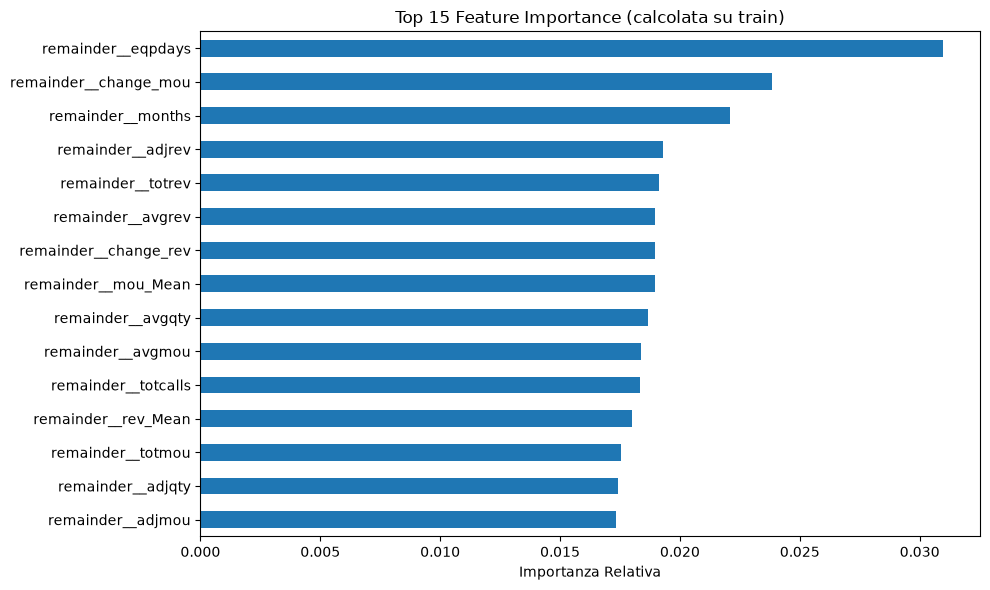

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Recupera i nomi delle feature DOPO il preprocessing (encoding incluso)
feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()

# Importanze dal RandomForest dentro la pipeline
importances = pipeline.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Top 15
top15 = feat_imp.head(15)
plt.figure(figsize=(10,6))
top15[::-1].plot(kind='barh')
plt.title('Top 15 Feature Importance (calcolata su train)')
plt.xlabel('Importanza Relativa')
plt.tight_layout()
plt.show()

Calcolo la correlazione tra variabili con Pearson per eliminare la ridondanza.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlazione solo sulle numeriche del train (mai sul test!)
corr = X_train[num_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Matrice di correlazione - variabili numeriche (train)')
plt.tight_layout()
plt.show()

# Trova le coppie con correlazione molto alta (>0.85), per identificare i doppioni
high_corr = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))  # esclude la diagonale
        .stack()
        .reset_index()
)
high_corr.columns = ['var1', 'var2', 'corr']
high_corr = high_corr[high_corr['corr'].abs() > 0.85].sort_values('corr', ascending=False)
print(high_corr.drop_duplicates(subset='corr'))  # rimuove i duplicati speculari (a,b) e (b,a)

Raggruppa le variabili in cluster usando la loro matrice di correlazione come "distanza", poi scegli un rappresentante per cluster:

In [15]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import numpy as np

# Trasforma la correlazione in una distanza
dist = 1 - corr.abs()

# Copia esplicita per avere un array scrivibile
dist_arr = dist.to_numpy(copy=True)
np.fill_diagonal(dist_arr, 0)

condensed_dist = squareform(dist_arr, checks=False)

# Clustering gerarchico
Z = linkage(condensed_dist, method='average')
clusters = fcluster(Z, t=0.15, criterion='distance')
cluster_map = pd.Series(clusters, index=corr.columns)

for c_id, group in cluster_map.groupby(cluster_map):
    members = group.index.tolist()
    if len(members) > 1:
        print(f"Cluster {c_id}: {members}")

#Scelgo un rappresentante per ogni cluster
representatives = []
for c_id, group in cluster_map.groupby(cluster_map):
    members = group.index.tolist()
    if len(members) == 1:
        representatives.append(members[0])
    else:
        # sceglie quella con importanza MDI più alta nel gruppo
        # nota: feat_imp ha i nomi con prefisso num__, va allineato
        members_clean = [m for m in members]
        best = feat_imp.reindex([f'num__{m}' for m in members_clean]).idxmax()
        best_clean = best.replace('num__', '')
        representatives.append(best_clean)

print(f"Feature numeriche finali: {len(representatives)} su {len(num_cols)}")
print(sorted(representatives))


In [10]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Configurazione stile
# sns.set_theme(style="whitegrid")
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# palette = ["#2b5c8f", "#d9534f"]  # Blu = Fedele (0), Rosso = Churn (1)

# # 1. Boxplot: Anzianità Dispositivo (eqpdays)
# sns.boxplot(
#     data=df_clean, x="churn", y="eqpdays", palette=palette, ax=axes[0, 0]
# )
# axes[0, 0].set_title(
#     "1. Anzianità Dispositivo (eqpdays) vs Churn", fontweight="bold"
# )
# axes[0, 0].set_xlabel("Churn (0 = No, 1 = Sì)")
# axes[0, 0].set_ylabel("Giorni possesso Smartphone")

# # 2. Boxplot: Mesi di Anzianità Cliente (months)
# sns.boxplot(
#     data=df_clean, x="churn", y="months", palette=palette, ax=axes[0, 1]
# )
# axes[0, 1].set_title(
#     "2. Anzianità Contrattuale (months) vs Churn", fontweight="bold"
# )
# axes[0, 1].set_xlabel("Churn (0 = No, 1 = Sì)")
# axes[0, 1].set_ylabel("Mesi di Permanenza")

# # 3. KDE Plot: Variazione Minuti Parlati (change_mou)
# sns.kdeplot(
#     data=df_clean,
#     x="change_mou",
#     hue="churn",
#     fill=True,
#     common_norm=False,
#     palette=palette,
#     ax=axes[1, 0],
#     clip=(-400, 400),
# )
# axes[1, 0].set_title(
#     "3. Variazione Minuti Parlati (change_mou) vs Churn", fontweight="bold"
# )
# axes[1, 0].set_xlabel("Variazione Minuti Parlati")
# axes[1, 0].set_ylabel("Densità")

# # 4. Barplot: Tasso di Churn per Tipologia Web Telefono (hnd_webcap Pulito)
# webcap_churn = (
#     df_clean.groupby("hnd_webcap")["churn"].mean() * 100
# ).reset_index()

# sns.barplot(
#     data=webcap_churn,
#     x="hnd_webcap",
#     y="churn",
#     color="#2b5c8f",
#     ax=axes[1, 1],
#     alpha=0.85,
# )
# axes[1, 1].axhline(
#     50, color="red", linestyle="--", label="Media Generale Churn (50%)"
# )
# axes[1, 1].set_title(
#     "4. Tasso di Churn (%) per Tipologia Web Telefono", fontweight="bold"
# )
# axes[1, 1].set_xlabel("Tipologia Web Dispositivo")
# axes[1, 1].set_ylabel("Tasso Medio di Churn (%)")
# axes[1, 1].legend()

# plt.tight_layout()
# plt.show()